# NB1 - The fNIRS signal and its physiology

*fNIRS block course - accompanies slides 8-16*

This notebook introduces **continuous-wave fNIRS** data and shows what the raw
signal actually contains. We use the open-access **resting-state dataset** of
[von Luhmann et al. (2020)](https://www.frontiersin.org/journals/neuroscience/articles/10.3389/fnins.2020.579353/full)
(Dataset I, occipital montage) and the **[cedalion](https://doc.ibs.tu-berlin.de/cedalion/)**
toolbox.

**What you will see**
1. Loading a `.snirf` recording and inspecting its contents
2. The optode **montage** (sources, detectors, channels)
3. **Source-detector distances** -> *long* vs *short* separation channels
4. The **raw light-intensity** time course of one channel
5. The **frequency content**: heartbeat (~1 Hz), respiration (~0.3 Hz),
   Mayer waves (~0.1 Hz)
6. Simultaneously-recorded **systemic signals** (PPG, respiration, blood pressure)

> Each notebook in this series runs top-to-bottom on the
> `cedalion_dev_260430` kernel.

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import xarray as xr
import h5py
import matplotlib.pyplot as plt
from scipy.signal import welch

import cedalion
import cedalion.io
import cedalion.nirs
import cedalion.dataclasses as cdc
from cedalion import units

plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["figure.dpi"] = 110

## Where the data lives

The recordings sit in `resting_state_1/` next to this notebook folder. Each
subject has a raw `resting.snirf` plus copies with a *synthetic* haemodynamic
response added (used in NB3). Here we use the **raw** resting-state file.

In [2]:
def find_data(subdir="resting_state_1"):
    """Locate the dataset folder. Download it from the NITRC links in the
    README and extract into ./data/ so you have data/resting_state_1/."""
    here = os.getcwd()
    for c in [os.path.join(here, "data", subdir),
              os.path.join(here, "..", "data", subdir),
              os.path.join(here, subdir),
              os.path.join(here, "..", subdir)]:
        if os.path.isdir(c):
            return os.path.abspath(c)
    raise FileNotFoundError(
        f"'{subdir}' not found. See the README: download the data from NITRC "
        f"and extract it into the data/ folder (data/{subdir}/).")

DATA = find_data("resting_state_1")
SUBJECT = "Subj33"
snirf_file = os.path.join(DATA, SUBJECT, "resting.snirf")
print("Reading:", snirf_file)
assert os.path.exists(snirf_file), "Data file not found - check the path above." 

Reading: c:\Users\josef\OneDrive\ETH\ETH Students Presentations Theses Reports\2026 Block Course Neuroimaging USZ\fnirs_notebooks\data\resting_state_1\Subj33\resting.snirf


### Helper functions

`cedalion.io.read_snirf` loads a recording. This dataset stores only **2-D**
optode coordinates in the SNIRF probe, so we build the geometry array
(`geo3d`) ourselves from the probe group - cedalion's distance/quality routines
just need a labelled position array with a length dimension.

In [3]:
def load_recording(path):
    """Read a SNIRF file and return (Recording, amplitude DataArray)."""
    rec = cedalion.io.read_snirf(path)[0]
    amp = rec["amp"]
    amp.time.attrs["units"] = "s"          # ensure a time unit is attached
    return rec, amp


def load_montage(path):
    """Build a labelled 2-D optode geometry (geo3d) from the SNIRF probe group."""
    with h5py.File(path, "r") as h:
        pr = h["nirs/probe"]
        src_labels = [s.decode() for s in np.array(pr["sourceLabels"])]
        det_labels = [d.decode() for d in np.array(pr["detectorLabels"])]
        src_pos = np.array(pr["sourcePos2D"])
        det_pos = np.array(pr["detectorPos2D"])

    labels = np.array(src_labels + det_labels)
    types = ([cdc.PointType.SOURCE] * len(src_labels)
             + [cdc.PointType.DETECTOR] * len(det_labels))
    pos = np.vstack([
        np.column_stack([src_pos, np.zeros(len(src_pos))]),
        np.column_stack([det_pos, np.zeros(len(det_pos))]),
    ])
    geo3d = xr.DataArray(
        pos, dims=["label", "pos"],
        coords={"label": ("label", labels), "type": ("label", types)},
        attrs={"units": "mm"},
    ).pint.quantify()
    return geo3d

In [4]:
rec, amp = load_recording(snirf_file)
geo3d = load_montage(snirf_file)

fs = float(1.0 / np.median(np.diff(amp.time.values)))
duration = float(amp.time.values[-1] - amp.time.values[0])

print(f"channels    : {amp.sizes['channel']}")
print(f"wavelengths : {list(amp.wavelength.values)} nm")
print(f"sampling    : {fs:.1f} Hz")
print(f"duration    : {duration:.0f} s")
print(f"amp dims    : {amp.dims}  shape {tuple(amp.shape)}")
print(f"first chans : {list(amp.channel.values[:6])}")

channels    : 34
wavelengths : [np.float64(690.0), np.float64(830.0)] nm
sampling    : 50.0 Hz
duration    : 302 s
amp dims    : ('channel', 'wavelength', 'time')  shape (34, 2, 15100)
first chans : ['S1D1', 'S1D5', 'S1D6', 'S2D2', 'S2D6', 'S2D7']


## The montage

Light travels from a **source** optode to a nearby **detector**; each
source-detector pair is one **channel**. The occipital montage of this dataset
has a regular grid of sources and detectors over the visual cortex.

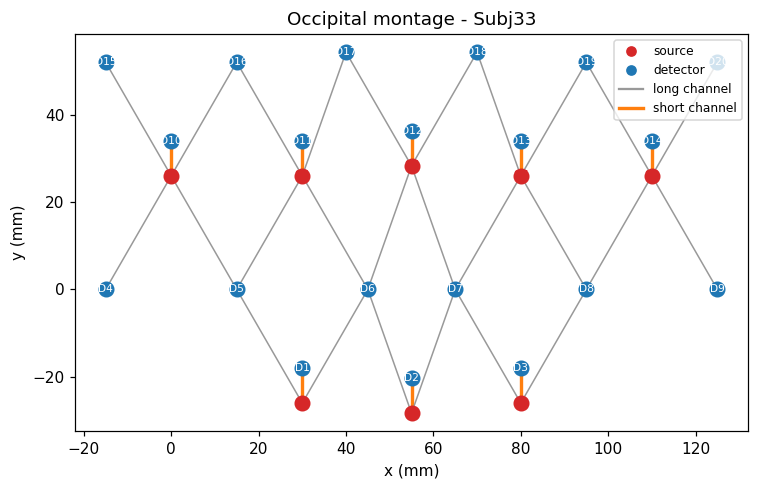

In [5]:
g = geo3d.pint.dequantify()
pos2d = {lab: g.sel(label=lab).values[:2] for lab in g.label.values}
is_src = {lab: (t == cdc.PointType.SOURCE) for lab, t in zip(g.label.values, g["type"].values)}

dists = cedalion.nirs.channel_distances(amp, geo3d).pint.to("mm")
d_mm = {ch: float(dists.sel(channel=ch)) for ch in amp.channel.values}

fig, ax = plt.subplots(figsize=(7, 7))
for ch, s, d in zip(amp.channel.values, amp.source.values, amp.detector.values):
    xs, ys = pos2d[s], pos2d[d]
    short = d_mm[ch] < 15.0
    ax.plot([xs[0], ys[0]], [xs[1], ys[1]],
            color="tab:orange" if short else "0.6",
            lw=2.2 if short else 1.0, zorder=1)
for lab, xy in pos2d.items():
    if is_src[lab]:
        ax.scatter(*xy, c="tab:red", s=90, zorder=3)
        ax.annotate(lab, xy, color="tab:red", fontsize=8, ha="center", va="center")
    else:
        ax.scatter(*xy, c="tab:blue", s=90, zorder=3)
        ax.annotate(lab, xy, color="white", fontsize=7, ha="center", va="center", zorder=4)
handles = [plt.Line2D([], [], c="tab:red", marker="o", ls="", label="source"),
           plt.Line2D([], [], c="tab:blue", marker="o", ls="", label="detector"),
           plt.Line2D([], [], c="0.6", label="long channel"),
           plt.Line2D([], [], c="tab:orange", lw=2.2, label="short channel")]
ax.legend(handles=handles, loc="upper right", fontsize=8)
ax.set_title(f"Occipital montage - {SUBJECT}")
ax.set_xlabel("x (mm)"); ax.set_ylabel("y (mm)"); ax.set_aspect("equal")
plt.tight_layout(); plt.show()

## Source-detector distance: long vs short channels

The **distance** between a source and detector sets how deep the light samples.

- **Long** channels (~3 cm) reach the **cortex** -> they carry the neural signal
  *plus* systemic "noise".
- **Short** channels (~0.8 cm) sample only **scalp/skull** -> they capture the
  systemic component and are later used as nuisance regressors (NB3).

`cedalion.nirs.split_long_short_channels` separates them at a distance
threshold.

long  channels: 26
short channels: 8


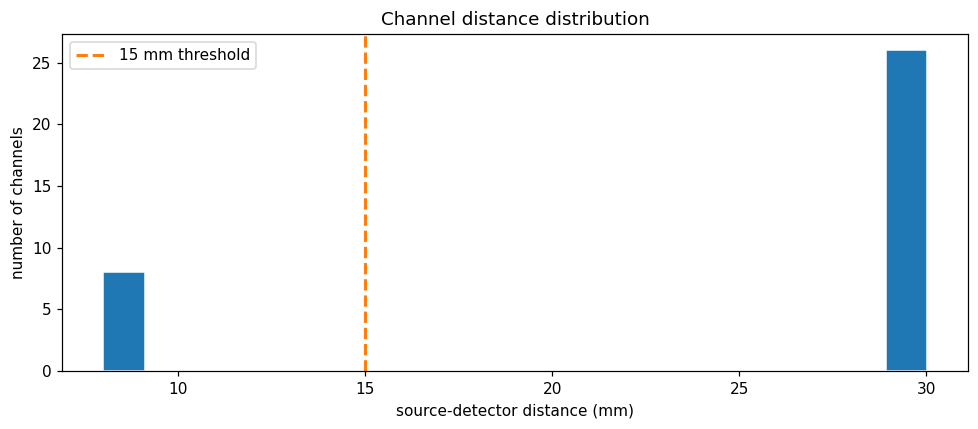

In [6]:
ts_long, ts_short = cedalion.nirs.split_long_short_channels(
    amp, geo3d, distance_threshold=1.5 * units.cm)
print(f"long  channels: {ts_long.sizes['channel']}")
print(f"short channels: {ts_short.sizes['channel']}")

fig, ax = plt.subplots()
ax.hist(list(d_mm.values()), bins=20, color="tab:blue", edgecolor="white")
ax.axvline(15, color="tab:orange", ls="--", lw=2, label="15 mm threshold")
ax.set_xlabel("source-detector distance (mm)")
ax.set_ylabel("number of channels")
ax.set_title("Channel distance distribution")
ax.legend(); plt.tight_layout(); plt.show()

## Raw light intensity over time

This is what the device records: the detected **light intensity** at each
wavelength. Notice the slow drift and the fast ripple riding on top - that
ripple is mostly the **heartbeat**.

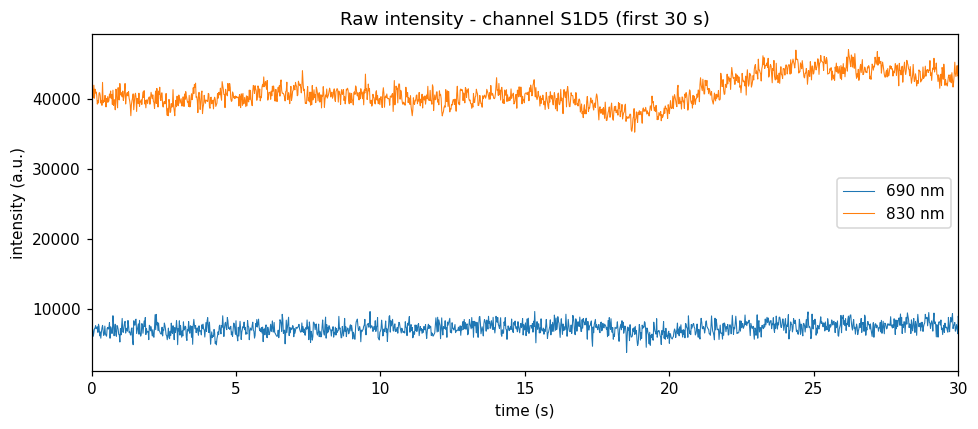

In [7]:
ch = str(ts_long.channel.values[0])
fig, ax = plt.subplots()
for wl in amp.wavelength.values:
    ax.plot(amp.time.values, amp.sel(channel=ch, wavelength=wl).values,
            lw=0.7, label=f"{int(wl)} nm")
ax.set_xlim(0, 30)
ax.set_xlabel("time (s)"); ax.set_ylabel("intensity (a.u.)")
ax.set_title(f"Raw intensity - channel {ch} (first 30 s)")
ax.legend(); plt.tight_layout(); plt.show()

## Frequency content - the physiology hiding in the signal

A power spectrum of a long channel reveals the **systemic rhythms** that every
fNIRS measurement contains:

| rhythm | frequency | origin |
|---|---|---|
| **Mayer waves** | ~0.1 Hz | blood-pressure oscillations |
| **respiration** | ~0.2-0.3 Hz | breathing |
| **cardiac** | ~1 Hz | heartbeat |

These dominate the raw signal and must be handled before the much smaller
neural response can be seen (NB2/NB3).

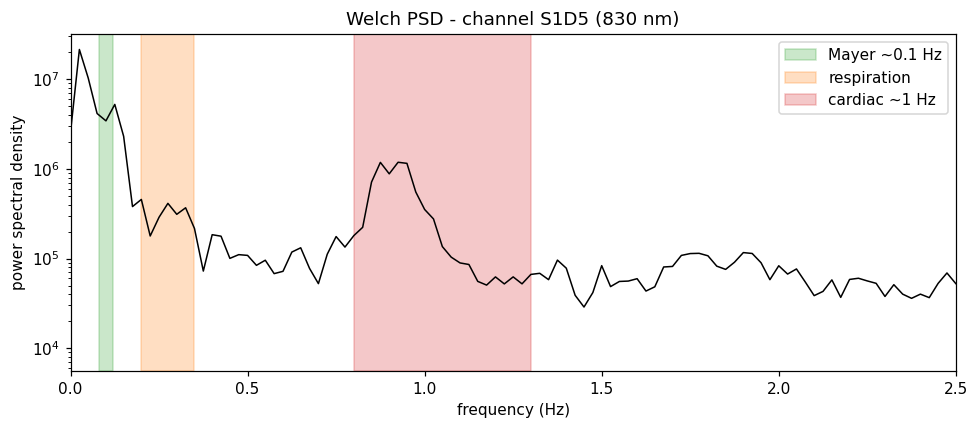

In [8]:
sig = amp.sel(channel=ch, wavelength=830.0).values
sig = sig - sig.mean()
f, pxx = welch(sig, fs=fs, nperseg=int(fs * 40))

fig, ax = plt.subplots()
ax.semilogy(f, pxx, color="k", lw=1)
for f0, f1, c, lab in [(0.08, 0.12, "tab:green", "Mayer ~0.1 Hz"),
                       (0.2, 0.35, "tab:orange", "respiration"),
                       (0.8, 1.3, "tab:red", "cardiac ~1 Hz")]:
    ax.axvspan(f0, f1, color=c, alpha=0.25, label=lab)
ax.set_xlim(0, 2.5)
ax.set_xlabel("frequency (Hz)"); ax.set_ylabel("power spectral density")
ax.set_title(f"Welch PSD - channel {ch} (830 nm)")
ax.legend(); plt.tight_layout(); plt.show()

## The systemic signals, measured directly

This dataset is **multimodal**: alongside fNIRS it recorded peripheral
physiology. In the raw file these auxiliary channels are unlabelled
(`aux1`-`aux8`); the dataset documentation (and the labelled copies) identify:

- `aux5` -> **PPG** (pulse / heartbeat)
- `aux6` -> **blood pressure**
- `aux7` -> **respiration**

Overlaying them confirms the spectral peaks above are genuinely systemic - the
same heartbeat that ripples through the fNIRS signal appears in the PPG.

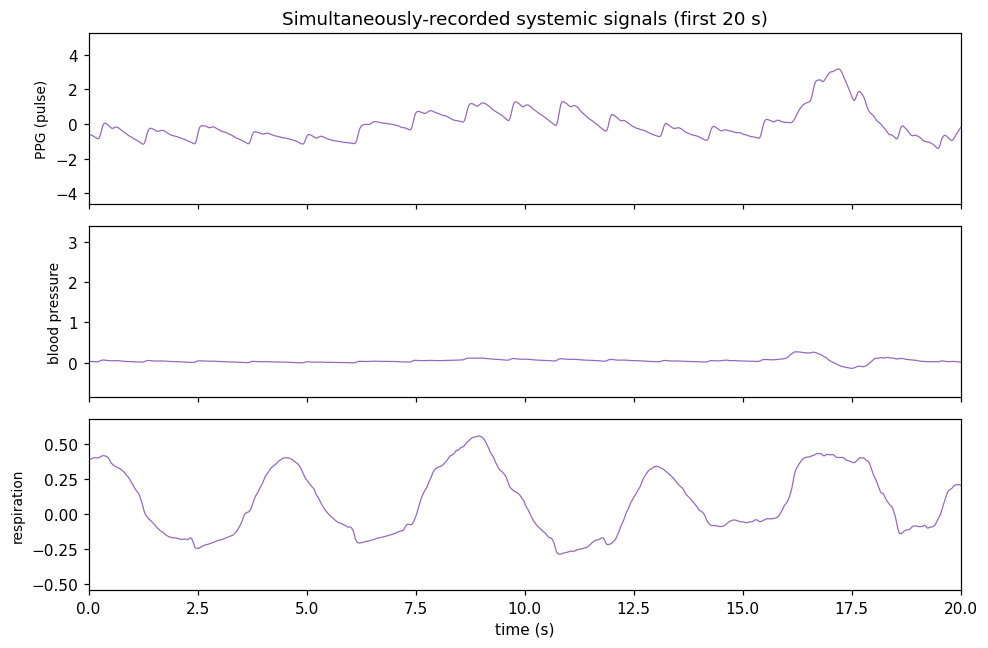

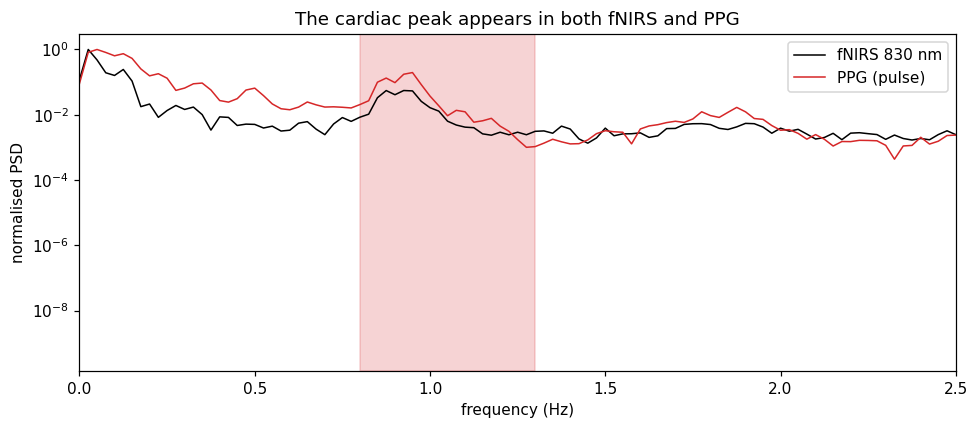

In [9]:
aux_map = {"PPG (pulse)": "aux5", "blood pressure": "aux6", "respiration": "aux7"}
t_aux = rec.aux_ts["aux5"].time.values

fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
for axx, (name, key) in zip(axes, aux_map.items()):
    v = np.asarray(rec.aux_ts[key].values).ravel()
    axx.plot(t_aux, v, lw=0.8, color="tab:purple")
    axx.set_ylabel(name, fontsize=9)
    axx.set_xlim(0, 20)
axes[-1].set_xlabel("time (s)")
axes[0].set_title("Simultaneously-recorded systemic signals (first 20 s)")
plt.tight_layout(); plt.show()

ppg = np.asarray(rec.aux_ts["aux5"].values).ravel(); ppg = ppg - ppg.mean()
fp, pp = welch(ppg, fs=fs, nperseg=int(fs * 40))
fig, ax = plt.subplots()
ax.semilogy(f, pxx / pxx.max(), label="fNIRS 830 nm", color="k", lw=1)
ax.semilogy(fp, pp / pp.max(), label="PPG (pulse)", color="tab:red", lw=1)
ax.axvspan(0.8, 1.3, color="tab:red", alpha=0.2)
ax.set_xlim(0, 2.5)
ax.set_xlabel("frequency (Hz)"); ax.set_ylabel("normalised PSD")
ax.set_title("The cardiac peak appears in both fNIRS and PPG")
ax.legend(); plt.tight_layout(); plt.show()

## Takeaways

- An fNIRS channel is a **source-detector pair**; distance controls sampling
  depth (**long** = cortex, **short** = scalp).
- The **raw intensity** is dominated by systemic rhythms - cardiac (~1 Hz),
  respiration (~0.3 Hz), Mayer waves (~0.1 Hz) - visible in the spectrum and
  confirmed by the simultaneously-recorded PPG / respiration / blood pressure.
- The neural haemodynamic response is **much smaller** and buried under this
  physiology.

**Next - NB2:** convert raw intensity into oxy-/deoxy-haemoglobin
concentrations via the modified Beer-Lambert law, and clean up the systemic
and motion artifacts.